=== 元データ列名 ===
['Date', 'Price']

=== 元データ先頭5行 ===
      Date  Price
0  1833-01  18.93
1  1833-02  18.93
2  1833-03  18.93
3  1833-04  18.93
4  1833-05  18.93

=== 日付変換・数値変換後 ===
Date     datetime64[ns]
Price           float64
dtype: object

=== 期間抽出後 ===
開始日: 1950-01-01 00:00:00
終了日: 2020-07-01 00:00:00
件数: 847
        Date  Price
0 1950-01-01  34.72
1 1950-02-01  34.72
2 1950-03-01  34.72
3 1950-04-01  34.72
4 1950-05-01  34.72
          Date    Price
842 2020-03-01  1591.93
843 2020-04-01  1683.17
844 2020-05-01  1715.91
845 2020-06-01  1732.22
846 2020-07-01  1846.51

保存しました：monthly_1950-01_2020-07.csv



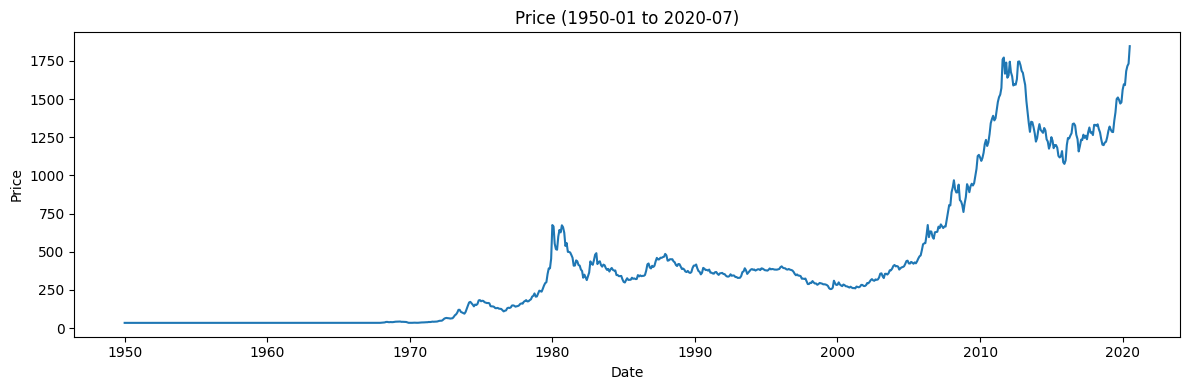

=== 季節差分後 ===
件数: 835
        Date  Price
0 1951-01-01    0.0
1 1951-02-01    0.0
2 1951-03-01    0.0
3 1951-04-01    0.0
4 1951-05-01    0.0

保存しました：seasonally_adjusted.csv



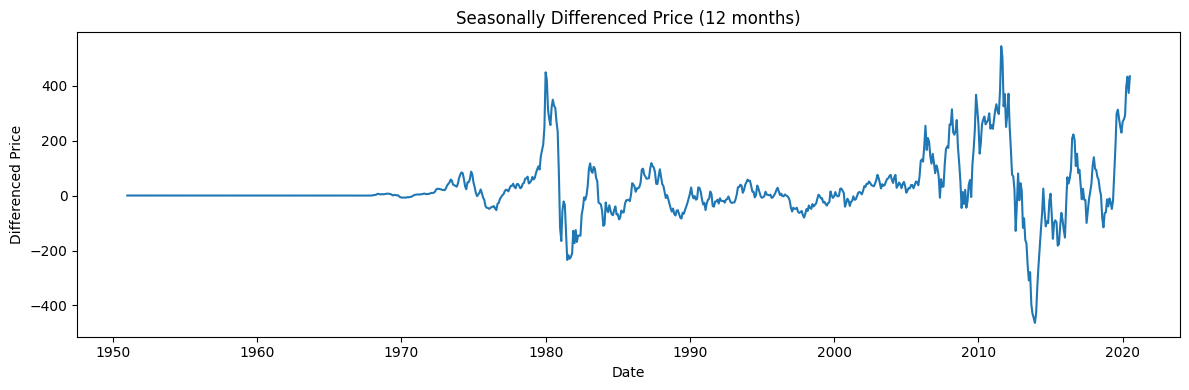

<Figure size 800x400 with 0 Axes>

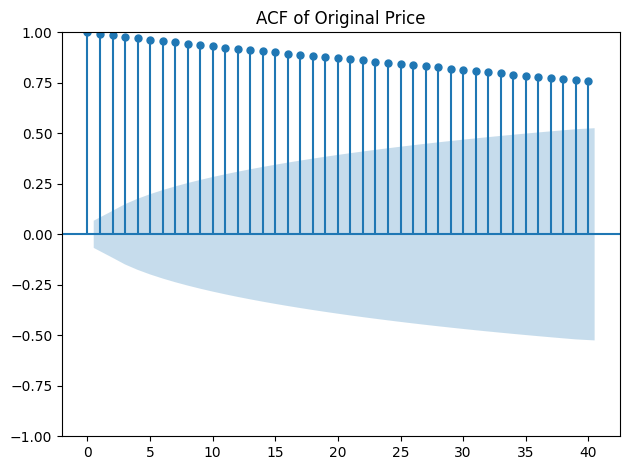

<Figure size 800x400 with 0 Axes>

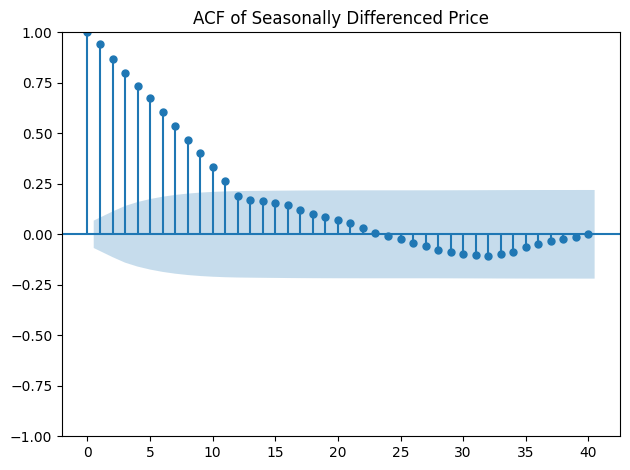

<Figure size 800x400 with 0 Axes>

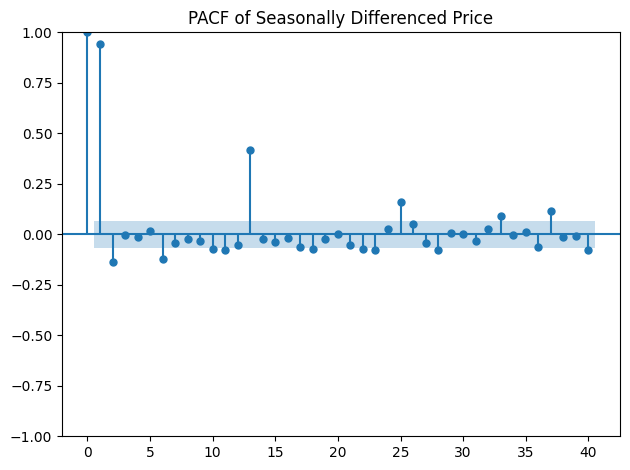

=== RandomForest 用データ ===
        Date  Price  lag_1  lag_2  lag_3  lag_6  lag_12  year  month
0 1952-01-01  -0.12   0.00   0.00   0.00    0.0     0.0  1952      1
1 1952-02-01  -0.12  -0.12   0.00   0.00    0.0     0.0  1952      2
2 1952-03-01  -0.12  -0.12  -0.12   0.00    0.0     0.0  1952      3
3 1952-04-01  -0.12  -0.12  -0.12  -0.12    0.0     0.0  1952      4
4 1952-05-01  -0.12  -0.12  -0.12  -0.12    0.0     0.0  1952      5

件数: 823

=== 説明変数 X 先頭 ===
   lag_1  lag_2  lag_3  lag_6  lag_12  year  month
0   0.00   0.00   0.00    0.0     0.0  1952      1
1  -0.12   0.00   0.00    0.0     0.0  1952      2
2  -0.12  -0.12   0.00    0.0     0.0  1952      3
3  -0.12  -0.12  -0.12    0.0     0.0  1952      4
4  -0.12  -0.12  -0.12    0.0     0.0  1952      5

=== 目的変数 y 先頭 ===
0   -0.12
1   -0.12
2   -0.12
3   -0.12
4   -0.12
Name: Price, dtype: float64

=== 学習・テスト分割 ===
X_train: (658, 7)
X_test : (165, 7)
y_train: (658,)
y_test : (165,)

学習完了

=== 評価指標 ===
RMSE: 83.0925451304418


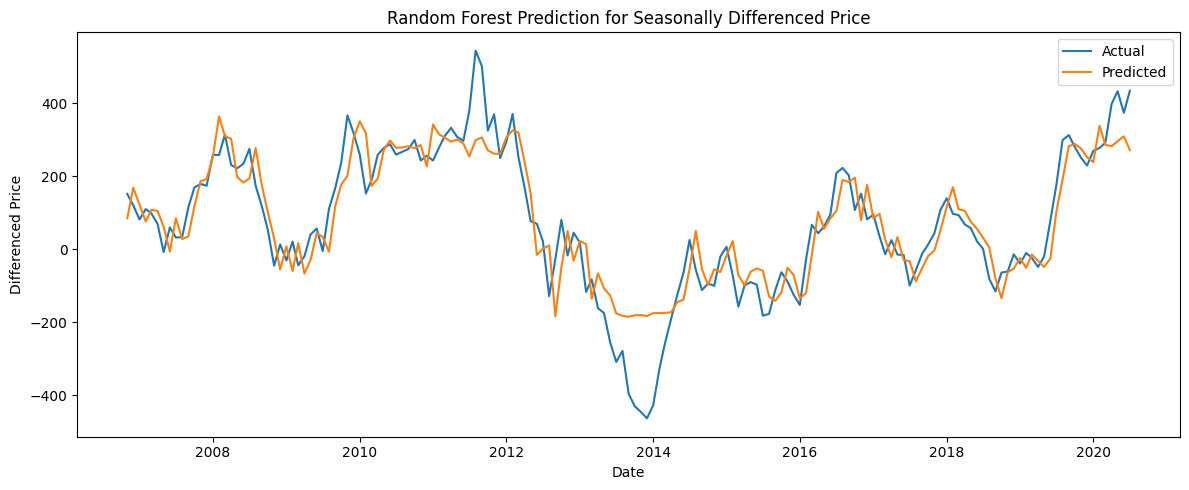

=== 特徴量重要度 ===
lag_1     0.885858
lag_2     0.037208
lag_12    0.025357
lag_3     0.017329
month     0.015316
lag_6     0.013933
year      0.004999
dtype: float64



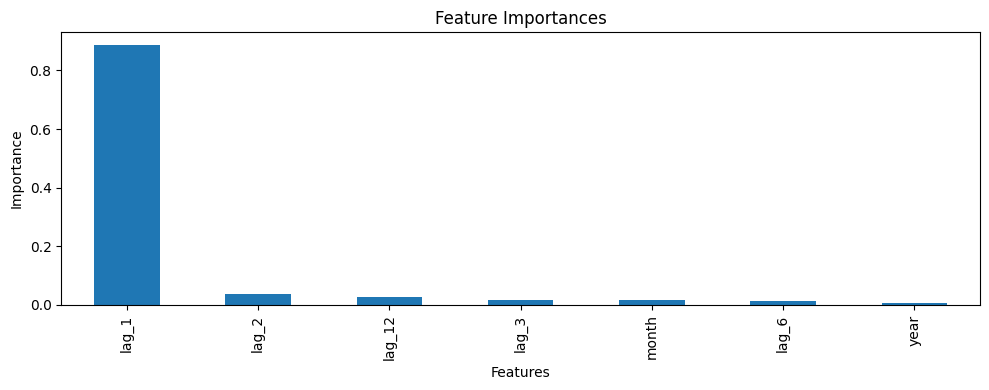

Selected Features:
lag_1
lag_2
lag_6
lag_12
Selected Features:


NameError: name 'dataframe' is not defined

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================
# 1. CSV読み込み
# =========================================
df = pd.read_csv("monthly.csv")

# 列確認
print("=== 元データ列名 ===")
print(df.columns.tolist())
print()

print("=== 元データ先頭5行 ===")
print(df.head())
print()

# =========================================
# 2. 日付変換
# =========================================
# Date列が文字列のままだと後でエラーになりやすいので datetime 化
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# 数値列も念のため数値化
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# 欠損があれば除去
df = df.dropna(subset=["Date", "Price"]).copy()

print("=== 日付変換・数値変換後 ===")
print(df.dtypes)
print()

# =========================================
# 3. 期間指定：1950-01 ～ 2020-07
# =========================================
start = pd.Timestamp("1950-01-01")
end   = pd.Timestamp("2020-07-01")

df_period = df[(df["Date"] >= start) & (df["Date"] <= end)].copy()

# 日付順に並べる
df_period = df_period.sort_values("Date").reset_index(drop=True)

print("=== 期間抽出後 ===")
print("開始日:", df_period["Date"].min())
print("終了日:", df_period["Date"].max())
print("件数:", len(df_period))
print(df_period.head())
print(df_period.tail())
print()

# =========================================
# 4. 抽出データ保存
# =========================================
df_period.to_csv("monthly_1950-01_2020-07.csv", index=False, encoding="utf-8-sig")
print("保存しました：monthly_1950-01_2020-07.csv")
print()

# =========================================
# 5. 元系列プロット
# =========================================
plt.figure(figsize=(12, 4))
plt.plot(df_period["Date"], df_period["Price"])
plt.title("Price (1950-01 to 2020-07)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# =========================================
# 6. 季節差分（12か月差分）
# =========================================
# あなたの元コードに近い形で、Price に対して 12期差分を取る
differenced = df_period.copy()
differenced["Price"] = df_period["Price"].diff(12)

# 最初の12行は NaN になる
differenced = differenced.dropna(subset=["Price"]).reset_index(drop=True)

print("=== 季節差分後 ===")
print("件数:", len(differenced))
print(differenced.head())
print()

# =========================================
# 7. 季節差分データ保存
# =========================================
differenced.to_csv("seasonally_adjusted.csv", index=False, encoding="utf-8-sig")
print("保存しました：seasonally_adjusted.csv")
print()

# =========================================
# 8. 季節差分後プロット
# =========================================
plt.figure(figsize=(12, 4))
plt.plot(differenced["Date"], differenced["Price"])
plt.title("Seasonally Differenced Price (12 months)")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.tight_layout()
plt.show()

# =========================================
# 9. ACF（元系列）
# =========================================
plt.figure(figsize=(8, 4))
plot_acf(df_period["Price"].dropna(), lags=40)
plt.title("ACF of Original Price")
plt.tight_layout()
plt.show()

# =========================================
# 10. ACF（季節差分後）
# =========================================
plt.figure(figsize=(8, 4))
plot_acf(differenced["Price"].dropna(), lags=40)
plt.title("ACF of Seasonally Differenced Price")
plt.tight_layout()
plt.show()

# =========================================
# 11. PACF（季節差分後）
# =========================================
plt.figure(figsize=(8, 4))
plot_pacf(differenced["Price"].dropna(), lags=40, method="ywm")
plt.title("PACF of Seasonally Differenced Price")
plt.tight_layout()
plt.show()

# =========================================
# 12. ランダムフォレスト用データ作成
# =========================================
# ここで大事なのは、Date をそのまま X に入れないこと
# 代わりにラグ特徴量、月、年などを作る

rf_df = differenced.copy()

# ラグ特徴量
# 直近1,2,3,6,12期前の季節差分値を特徴量にする
for lag in [1, 2, 3, 6, 12]:
    rf_df[f"lag_{lag}"] = rf_df["Price"].shift(lag)

# カレンダー特徴量
rf_df["year"] = rf_df["Date"].dt.year
rf_df["month"] = rf_df["Date"].dt.month

# 目的変数は季節差分後の Price
# ラグ生成で先頭側に欠損が出るので削除
rf_df = rf_df.dropna().reset_index(drop=True)

print("=== RandomForest 用データ ===")
print(rf_df.head())
print()
print("件数:", len(rf_df))
print()

# =========================================
# 13. 説明変数X・目的変数y
# =========================================
feature_cols = [
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "year", "month"
]

X = rf_df[feature_cols]
y = rf_df["Price"]

print("=== 説明変数 X 先頭 ===")
print(X.head())
print()
print("=== 目的変数 y 先頭 ===")
print(y.head())
print()

# =========================================
# 14. 学習・テスト分割
# =========================================
# 時系列なのでシャッフルせず、前80%を学習、後20%をテスト
split_idx = int(len(rf_df) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

date_train = rf_df["Date"].iloc[:split_idx].copy()
date_test  = rf_df["Date"].iloc[split_idx:].copy()

print("=== 学習・テスト分割 ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print()

# =========================================
# 15. ランダムフォレスト学習
# =========================================
model = RandomForestRegressor(
    n_estimators=500,
    random_state=1,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("学習完了")
print()

# =========================================
# 16. 予測
# =========================================
y_pred = model.predict(X_test)

# =========================================
# 17. 評価
# =========================================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== 評価指標 ===")
print(f"RMSE: {rmse}")
print(f"MAE : {mae}")
print(f"R^2 : {r2}")
print()

# =========================================
# 18. 予測結果をDataFrame化して保存
# =========================================
result_df = pd.DataFrame({
    "Date": date_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("=== 予測結果先頭 ===")
print(result_df.head())
print()

result_df.to_csv("rf_forecast_result.csv", index=False, encoding="utf-8-sig")
print("保存しました：rf_forecast_result.csv")
print()

# =========================================
# 19. 実測値と予測値のプロット
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(date_test, y_test.values, label="Actual")
plt.plot(date_test, y_pred, label="Predicted")
plt.title("Random Forest Prediction for Seasonally Differenced Price")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================
# 20. 特徴量重要度
# =========================================
importance = pd.Series(model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

print("=== 特徴量重要度 ===")
print(importance)
print()

plt.figure(figsize=(10, 4))
importance.plot(kind="bar")
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


from sklearn.feature_selection import RFE
# perform feature selection
rfe = RFE(RandomForestRegressor(n_estimators=500, random_state=1), n_features_to_select=4)
fit = rfe.fit(X, y)

print("Selected Features:")
names = feature_cols
for i in range(len(fit.support_)):
    if fit.support_[i]:
        print(names[i])

# 2026-04-02

from sklearn.feature_selection import RFE
# perform feature selection
rfe = RFE(RandomForestRegressor(n_estimators=500, random_state=1), n_features_to_select=4)
fit = rfe.fit(X, y)

# report selected features
print('Selected Features:')
names = dataframe.columns.values[0:-1]
for i in range(len(fit.support_)):
    if fit.support_[i]:
        print(names[i])

# plot feature rank
names = dataframe.columns.values[0:-1]
ticks = [i for i in range(len(names))]
plt.bar(ticks, fit.ranking_)
plt.xticks(ticks, names)
plt.show()